# Importing Dataset
The White Wine Quality dataset from the UCI Machine Learning Repository contains 4,898 instances of Portuguese "Vinho Verde" white wine, detailing 11 physicochemical input variables (e.g., density, pH, alcohol, residual sugar) and a quality rating (output) from 0–10. This dataset is primarily used for regression task.

In [74]:
# Import pandas API
import pandas as pd

# Read the input csv file
dataset = pd.read_csv(r'C:\Users\Predator\Desktop\emlearn Examples\Dataset\winequality-white.csv')

# Display 10 random samples from the dataset
dataset.sample(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1507,7.8,0.26,0.74,7.5,0.044,59.0,160.0,0.99600,3.22,0.64,10.0,6
3732,7.5,0.28,0.41,1.3,0.044,11.0,126.0,0.99293,3.28,0.45,10.3,5
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
2639,9.2,0.14,0.37,1.1,0.034,36.0,84.0,0.99136,3.05,0.55,11.6,6
4665,7.3,0.17,0.36,8.2,0.028,44.0,111.0,0.99272,3.14,0.41,12.4,6
1416,6.6,0.23,0.26,1.3,0.045,16.0,128.0,0.99340,3.36,0.60,10.0,6
652,7.1,0.26,0.34,14.4,0.067,35.0,189.0,0.99860,3.07,0.53,9.1,7
1143,7.2,0.24,0.30,1.6,0.048,27.0,131.0,0.99330,3.25,0.45,10.5,5
3615,7.2,0.24,0.30,1.2,0.037,11.0,95.0,0.98914,2.96,0.36,12.5,6
1096,6.5,0.28,0.26,8.8,0.040,44.0,139.0,0.99560,3.32,0.37,10.2,6


# Splitting the Feature Variables and Target Variable
Based on the standard "White Wine Quality" dataset (commonly found in the UCI Machine Learning Repository), the dataset consists of 11 physicochemical input variables as features and a whine quality score variable as target.
* Target Variable (quality): The wine quality score rating, typically ranging from 0 to 10.
* Features Varaible: 11 physicochemical variables such as fixed acidity, volatile acidity, ..., and alcohol

In [75]:
# Separate the features variables from the target variable
X = dataset.drop(['quality'], axis=1)

# Display 10 random samples of features
X.sample(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
1215,8.0,0.28,0.42,7.10,0.045,41.0,169.0,0.99590,3.17,0.43,10.6
406,5.8,0.28,0.34,4.00,0.031,40.0,99.0,0.98960,3.39,0.39,12.8
2005,7.0,0.28,0.33,14.60,0.043,47.0,168.0,0.99940,3.34,0.67,8.8
2940,7.1,0.29,0.34,7.80,0.036,49.0,128.0,0.99397,3.21,0.40,10.7
2884,7.0,0.28,0.32,7.75,0.032,30.0,114.0,0.99158,3.12,0.64,12.8
4101,6.9,0.37,0.23,9.50,0.057,54.0,166.0,0.99568,3.23,0.42,10.0
3042,6.3,0.33,0.42,17.20,0.037,57.0,170.0,0.99884,3.26,0.57,9.4
1861,7.8,0.20,0.28,10.20,0.054,78.0,186.0,0.99700,3.14,0.46,10.0
376,6.4,0.31,0.28,1.50,0.037,12.0,119.0,0.99190,3.32,0.51,10.4
4236,6.4,0.29,0.18,15.00,0.040,21.0,116.0,0.99736,3.14,0.50,9.2


In [76]:
# Separate the target variable
y = dataset['quality']

# Display 10 random samples of target variable
y.sample(10)

4352    5
4307    7
716     6
209     6
386     7
142     6
1083    6
2101    6
246     7
166     6
Name: quality, dtype: int64

# Visualaszing Features and Target Variables Correlation
Understanding the relationship between the physicochemical features and the target variable (`quality`) is crucial for regression analysis. Visualizing these correlations helps identify which features are most influential in predicting wine quality.

Common visualization technique is scatter plots with regression lines show how individual features relate to quality. The `regplot` in the Seaborn library is a linear model plot used for visualizing the linear relationship between two continuous variables in the data. It plots a scatter plot of data points and a fitted linear regression line with a 95% confidence interval. It is essential for visualizing the trend and relationship between two continuous variables.

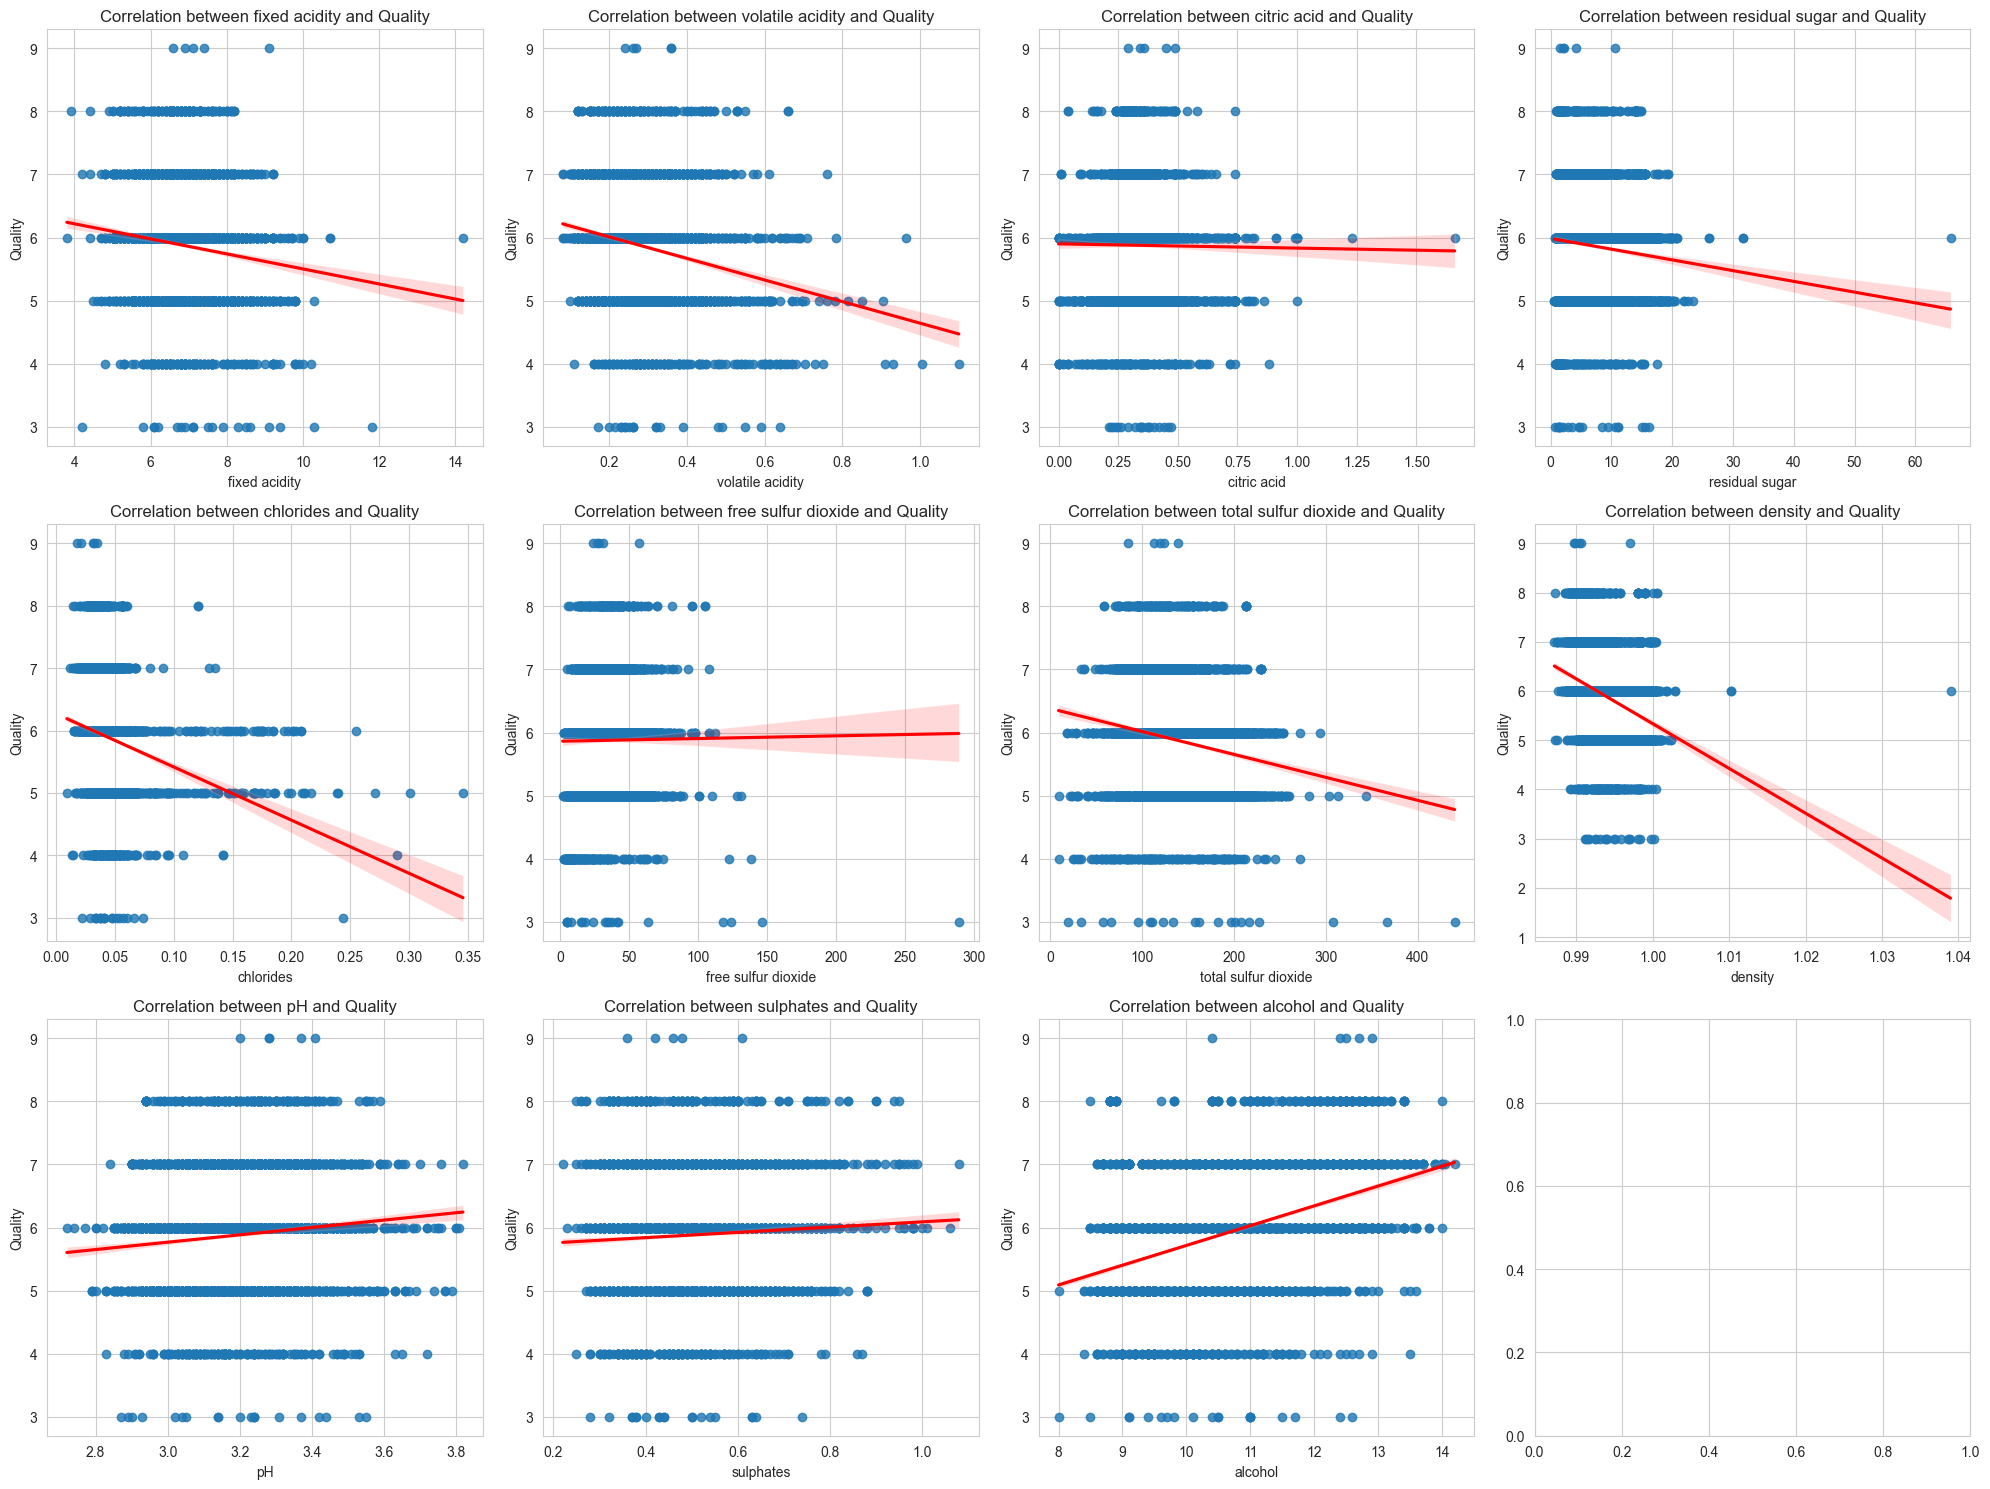

In [77]:
# Visualize the correlation between the features and the target variable
import seaborn as sns
import matplotlib.pyplot as plt

# Set the style of the plots
sns.set_style('whitegrid')

# Create a subplot grid
fig, axes = plt.subplots(3, 4, figsize=(20, 15))

# Loop through each feature and create a scatter plot with a regression line
for i, feature in enumerate(X.columns):
    row = i // 4    # Determine the row index
    col = i % 4     # Determine the column index

    # Create a scatter plot with a regression line for the current feature against the target variable
    sns.regplot(
        x=feature,
        y='quality',
        data=dataset,
        ax=axes[row, col],
        line_kws={"color": "red"}
    )

    # Set the title and labels for the current subplot
    axes[row, col].set_title(f'Correlation between {feature} and Quality')
    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel('Quality')

# Adjust layout and display the plots
plt.tight_layout()
plt.show()

## Dataset Features Analysis
Dataset feature analysis for regression involves selecting relevant, numerical input variables $X$ to predict a continuous target $y$. Key steps include analyzing feature-target correlations, removing multicollinearity between predictors, handling outliers, and ensuring data linearity. Techniques include feature selection, correlation matrices, and visualization.

The most common method is the **Pearson correlation coefficient**, which measures the linear relationship between numerical variables. The correlation coefficients range from $-1$ to $1$.
$$
r = \frac{\sum_{i=1}^n (X_i - \bar{X})(Y_i - \bar{Y})}{\sqrt{\sum_{i=1}^n (X_i - \bar{X})^2} \sqrt{\sum_{i=1}^n (Y_i - \bar{Y})^2}}
$$
Where:
- $X_i$, $Y_i$ are the individual sample points
- $\bar{X}$, $\bar{Y}$ are the means of $X$ and $Y$
- $n$ is the number of samples

Interpretation:
* **Values near 1**: Strong positive linear correlation (as one variable increases, the other tends to increase).
* **Values near -1**: Strong negative linear correlation (as one variable increases, the other tends to decrease).
* **Values near 0**: No significant linear correlation. 

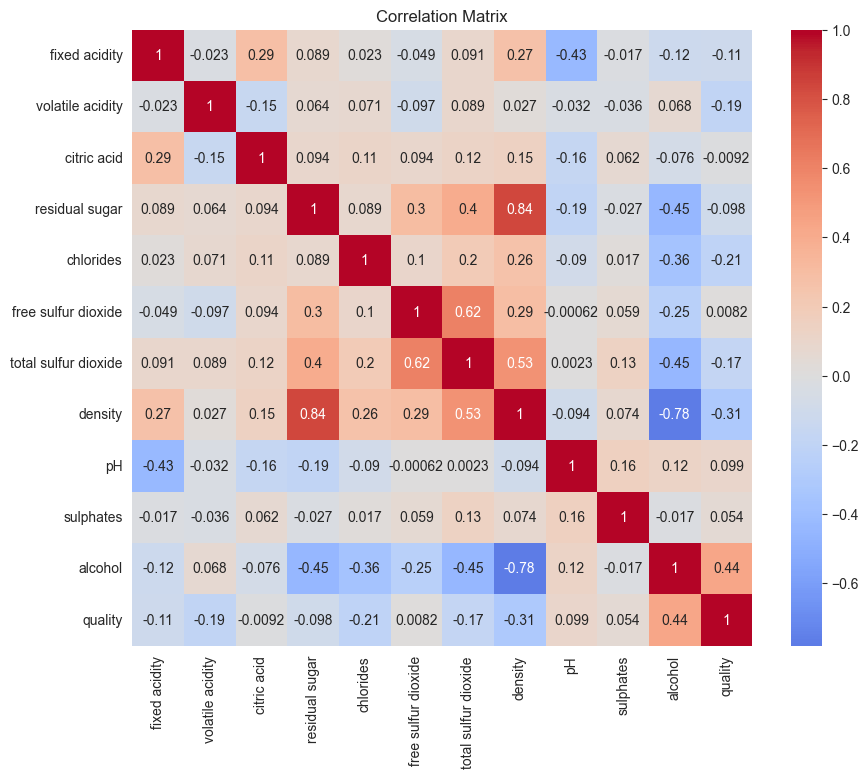

In [78]:
# Import seaborn and matplotlib for visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix using Pearson's method
correlation_matrix = dataset.corr(method='pearson')

# Create a heatmap of the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

In [79]:
print(correlation_matrix['quality'].sort_values(ascending=False))

quality                 1.000000
alcohol                 0.435575
pH                      0.099427
sulphates               0.053678
free sulfur dioxide     0.008158
citric acid            -0.009209
residual sugar         -0.097577
fixed acidity          -0.113663
total sulfur dioxide   -0.174737
volatile acidity       -0.194723
chlorides              -0.209934
density                -0.307123
Name: quality, dtype: float64


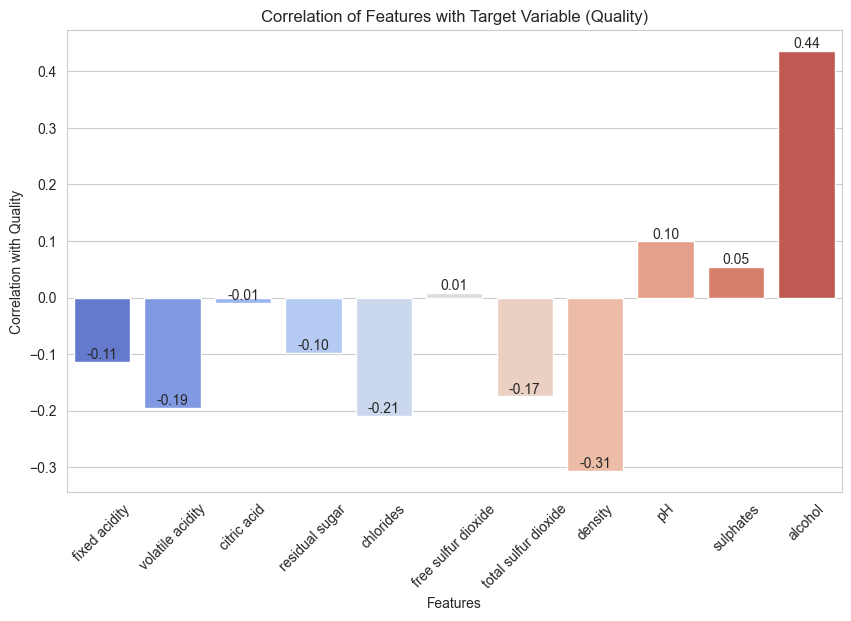

In [80]:
# Plot the correlation score of each feature with the target variable using a bar plot
plt.figure(figsize=(10, 6))

# Extract the correlation of each feature with the target variable
features_corr_with_target = dataset.corr(method='pearson')['quality'].drop('quality')

# Create a bar plot of the correlation scores with the target variable each bar has a score value on top of it
sns.barplot(x=features_corr_with_target.index, y=features_corr_with_target.values, hue=features_corr_with_target.index, palette='coolwarm', legend=False)
plt.title('Correlation of Features with Target Variable (Quality)')
plt.xlabel('Features')
plt.ylabel('Correlation with Quality')
plt.xticks(rotation=45)
# Add correlation score values on top of each bar
for index, value in enumerate(features_corr_with_target.values):
    plt.text(index, value, f'{value:.2f}', ha='center', va='bottom')
plt.show()

# Features Selection

Feature selection for regression optimizes model performance and interpretability by selecting relevant, non-redundant input variables (predictors) to predict a continuous target. It helps reduce overfitting, improve accuracy, and decrease training time.

### Common Feature Selection Methods

- **SelectKBest**: Selects the top $k$ features based on a scoring function. For regression, common scoring functions includes **ANOVA F-value** (`f_regression`) that measures the linear dependency between each feature and the target variable.
- **SelectPercentile**: Selects a user-specified top percentage of features based on a scoring function (e.g., top 20% most correlated features).

These methods help identify the most informative features, leading to simpler and more robust models.

In [ ]:
# Features selection using SelectKBest with f_regression method
from sklearn.feature_selection import SelectKBest, f_regression

# Initialize the feature selector
selector = SelectKBest(score_func=f_regression, k=7)  # Select top 7 features

# Fit the selector on the training data
selector.fit_transform(X, y)

# Transform the test data using the same selector
X_selected = selector.transform(X)

# Display the top 5 features selected by SelectKBest with score values
selected_features = X.columns[selector.get_support()]
feature_scores = selector.scores_[selector.get_support()]
print("Selected Features and their Scores:")
for feature, score in sorted(
    zip(selected_features, feature_scores),
    key=lambda x: x[1],
    reverse=True
):
    print(f"{feature}: {score:.2f}")

Selected Features and their Scores:
alcohol: 1146.40
density: 509.91
chlorides: 225.73
volatile acidity: 192.96
total sulfur dioxide: 154.20
fixed acidity: 64.08
pH: 48.88


In [82]:
# Features selection using SelectPercentile with f_regression method
from sklearn.feature_selection import SelectPercentile, f_regression

# Initialize the feature selector
selector_percentile = SelectPercentile(score_func=f_regression, percentile=70)  # Select top 70% features

# Fit the selector on the training data
selector_percentile.fit_transform(X, y)

# Transform the test data using the same selector
X_selected_percentile = selector_percentile.transform(X)

# Display the features selected by SelectPercentile with score values
selected_features_percentile = X.columns[selector_percentile.get_support()]
feature_scores_percentile = selector_percentile.scores_[selector_percentile.get_support()]
print("Selected Features by Percentile and their Scores:")
for feature, score in sorted(
    zip(selected_features_percentile, feature_scores_percentile),
    key=lambda x: x[1],
    reverse=True
):
    print(f"{feature}: {score:.2f}")

Selected Features by Percentile and their Scores:
alcohol: 1146.40
density: 509.91
chlorides: 225.73
volatile acidity: 192.96
total sulfur dioxide: 154.20
fixed acidity: 64.08
pH: 48.88


In [83]:
# Create a dataframe consist to selected features and target variable
selected_features_df = pd.DataFrame(X_selected, columns=selected_features)

# Display the random 5 rows of the dataframe with selected features and target variable
selected_features_df.sample(5)

,fixed acidity,volatile acidity,chlorides,total sulfur dioxide,density,pH,alcohol
2786,8.0,0.30,0.034,70.0,0.99354,3.05,12.2
534,7.4,0.25,0.067,178.0,0.99760,3.01,9.0
3270,6.4,0.15,0.044,115.0,0.99166,3.10,10.2
2950,6.0,0.28,0.042,108.0,0.99290,3.08,9.0
3732,7.5,0.28,0.044,126.0,0.99293,3.28,10.3


# Dataset Preprocessing
### Normalizing the Features Data
Normalizing feature data (scaling to a 0-1 range or standardizing to mean=0, std=1) before fitting a regression model is crucial when features have vastly different scales. It prevents features with larger magnitudes from dominating, speeds up gradient descent convergence, and ensures regularization treats all features equally.

In this example, we will use `MinMaxScaler` to normalize the features to a range from `0` to `1` to prevent features with larger magnitudes from dominating the model.

For a given data point $X$, the Min-Max scaled value $X_{scaled}$ is calculated as: 
$$
X_{scaled}=\frac{X-X_{min}}{X_{max}-X_{min}}
$$

In [84]:
# Normalize the dataset features using MinMaxScaler
from sklearn.preprocessing import MinMaxScaler

# Create an instance of the MinMaxScaler
scaler = MinMaxScaler()

# Fit the scaler to the features and transform them
X_scaled = scaler.fit_transform(selected_features_df.astype('float32'))

# Display some random samples of the scaled features
pd.DataFrame(X_scaled, columns=selected_features_df.columns).sample(10)

,fixed acidity,volatile acidity,chlorides,total sulfur dioxide,density,pH,alcohol
3578,0.278846,0.137255,0.086053,0.266821,0.074610,0.345454,0.516129
1070,0.403846,0.284314,0.091988,0.364269,0.094273,0.254545,0.532258
3895,0.307692,0.166667,0.035608,0.155452,0.059763,0.490909,0.693548
3918,0.250000,0.264706,0.083086,0.241299,0.013107,0.363636,1.000000
4658,0.317308,0.343137,0.080119,0.285383,0.050896,0.445455,0.870968
1454,0.432692,0.127451,0.133531,0.515081,0.271639,0.245455,0.193548
1220,0.250000,0.147059,0.103858,0.483759,0.094273,0.554545,0.483871
4724,0.221154,0.235294,0.080119,0.206497,0.156158,0.563636,0.354839
1999,0.336539,0.098039,0.136499,0.436195,0.252361,0.372727,0.161290
843,0.298077,0.107843,0.080119,0.213457,0.116444,0.445455,0.451613


In [85]:
# print scaler min and max values
print("Min values for each feature:")
print(scaler.data_min_.astype('float32'))
print("\nMax values for each feature:")
print(scaler.data_max_.astype('float32'))

# print the scaler parameters
print("\nScaler parameters:")
print(f"Feature range: {scaler.feature_range}")

Min values for each feature:
[3.8000e+00 8.0000e-02 9.0000e-03 9.0000e+00 9.8711e-01 2.7200e+00
 8.0000e+00]

Max values for each feature:
[1.42000e+01 1.10000e+00 3.46000e-01 4.40000e+02 1.03898e+00 3.82000e+00
 1.42000e+01]

Scaler parameters:
Feature range: (0, 1)


# Splitting the Dataset into Training, Testing, and Validation Set
Splitting a dataset is a crucial step in machine learning to evaluate model performance and prevent overfitting. Typically, the data is divided into three sets:
- **Training Set**: Used to train the model.
- **Testing Set**: Used to assess the final model performance.

A common approach is to split the dataset into training and testing sets.

<img src="https://cdn.imweb.me/upload/S202105076e626e4618b27/0f0c2df8f341c.png">

In [86]:
# Include Train test set split function from scikit-learn
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, shuffle=True, stratify=y)

# Print the shapes of the training and test sets
print("Training features shape:", X_train.shape)
print("Training targets shape:", y_train.shape)
print("Test features shape:", X_test.shape)
print("Test targets shape:", y_test.shape)

Training features shape: (3918, 7)
Training targets shape: (3918,)
Test features shape: (980, 7)
Test targets shape: (980,)


# Training a Tree-Based Regression Models
Tree-based regression models use a decision tree to predict a continuous target variable by recursively partitioning the data into smaller, more homogeneous subsets. The prediction for any given data point is the average of the target values within the final subset (leaf node) it falls into.

`sklearn` provides three popular classes for tree-based regression: `DecisionTreeRegressor`, `RandomForestRegressor`, and `ExtraTreesRegressor`.

### DecisionTreeRegressor
This is a single tree that predicts a numerical value by partitioning data into smaller groups based on simple rules. At each leaf node, the prediction is the average of the target values of all samples in that node.

### RandomForestRegressor
It is a powerful ensemble machine learning algorithm that predicts continuous numerical values by averaging predictions from multiple decision trees trained on random data subsets. It reduces overfitting and improves accuracy by combining these models.

### ExtraTreesRegressor
It is an ensemble machine learning algorithm that fits multiple randomized decision trees on sub-samples of a dataset. It is similar to Random Forest but introduces additional randomness in the tree-building process to improve performance and reduce overfitting.

In [87]:
# Import the Decision Tree Regressor algorithm from scikit-learn
from sklearn.tree import DecisionTreeRegressor

# Retrain the regression model using the Decision Tree Regressor algorithm on the selected features
dt_regressor = DecisionTreeRegressor(random_state=42, max_depth=20)

# Fit the regressor to the training data
dt_regressor.fit(X_train.astype('float32'), y_train.astype('float32'))

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_lea

In [88]:
# Import the Random Forest Regressor algorithm from scikit-learn
from sklearn.ensemble import RandomForestRegressor

# Retrain the regression model using the Random Forest Regressor algorithm on the selected features
rf_regressor = RandomForestRegressor(n_estimators=10, random_state=42, max_depth=20)

# Fit the regressor to the training data
rf_regressor.fit(X_train.astype('float32'), y_train.astype('float32'))

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [89]:
# Import the Extra Trees Regressor algorithm from scikit-learn
from sklearn.ensemble import ExtraTreesRegressor

# Train the regression model using the Extra Trees Regressor algorithm on the scaled features
et_regressor = ExtraTreesRegressor(n_estimators=10, random_state=42, max_depth=20)

# Fit the regressor to the training data
et_regressor.fit(X_train.astype('float32'), y_train.astype('float32'))

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the num

# Test Prediction for Trained Regression Model
After training a regression model, it is important to evaluate its performance on unseen data. This is typically done by making predictions on the test set and comparing them to the actual target values.

**Key Steps:**
- Use the trained regression model to predict target values for the test set features.
- Compare the predicted values with the actual test set targets.
- Analyze the prediction errors to assess model performance.

**Purpose:**
- To estimate how well the model generalizes to new, unseen data.
- To identify potential issues such as overfitting or underfitting.

**Common Practices:**
- Display a few random test samples with their actual and predicted values.
- Calculate and report error metrics (e.g., MAE, MSE, RMSE, $R^2$) for the test set.

This process provides a realistic measure of the model's predictive power and helps guide further model improvement.

In [112]:
# Select a random sample of test features for predection
import random as round

# Generate random indices for selecting test samples
random_indices = round.sample(range(X_test.shape[0]), 1)

# Select the random samples from the test set
X_test_sample = X_test[random_indices]
y_test_sample = y_test.iloc[random_indices]

# Inverse transform the scaled data back to original form
X_test_sample_raw = scaler.inverse_transform(X_test_sample)

# Print the selected random samples of test features (CSV) and their corresponding target values
print("Selected Random Test Features (Raw):")
print(pd.DataFrame(X_test_sample_raw, columns=selected_features_df.columns).to_csv(index=False))
print("Selected Random Test Features (Scaled):")
print(pd.DataFrame(X_test_sample.astype('float32'), columns=selected_features_df.columns).to_csv(index=False))
print("Corresponding Target Values:")
print(y_test_sample)

Selected Random Test Features (Raw):
fixed acidity,volatile acidity,chlorides,total sulfur dioxide,density,pH,alcohol
6.7,0.16,0.046,153.0,0.9921,3.38,11.4

Selected Random Test Features (Scaled):
fixed acidity,volatile acidity,chlorides,total sulfur dioxide,density,pH,alcohol
0.27884617,0.07843137,0.10979229,0.3341067,0.09620094,0.60000014,0.54838705

Corresponding Target Values:
1751    7
Name: quality, dtype: int64


In [113]:
# Do predictions using the trained Decision Tree Regressor, Random Forest Regressor, and Extra Trees Regressor on the selected random test sample
dt_prediction = dt_regressor.predict(X_test_sample.astype('float32'))
rf_prediction = rf_regressor.predict(X_test_sample.astype('float32'))
et_prediction = et_regressor.predict(X_test_sample.astype('float32'))

print(f"Prediction using Decision Tree Regressor: {dt_prediction[0]:.2f}")
print(f"Prediction using Random Forest Regressor: {rf_prediction[0]:.2f}")
print(f"Prediction using Extra Trees Regressor: {et_prediction[0]:.2f}")

Prediction using Decision Tree Regressor: 7.00
Prediction using Random Forest Regressor: 6.70
Prediction using Extra Trees Regressor: 7.00


### Performance Metrics
Tree-based regression models should be evaluated on a held-out test set rather than on the training data alone.

In this section, the models are compared using four standard regression metrics:
- **MAE (Mean Absolute Error):** average absolute prediction error. Lower is better.
- **MSE (Mean Squared Error):** average squared prediction error. Lower is better.
- **RMSE (Root Mean Squared Error):** square root of MSE, expressed in the target variable's units. Lower is better.
- **$R²$ Score:** proportion of variance explained by the model. Higher is better, with `1.0` being a perfect fit.

In [92]:
# Import evaluation metrics from scikit-learn
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

# Create fresh models for a fair evaluation on the held-out test set
evaluation_models = {
    'Decision Tree': dt_regressor,
    'Random Forest': rf_regressor,
    'Extra Trees': et_regressor,
}

# Evaluate each model and store the results in a list of dictionaries
evaluation_rows = []

# Fit each model, make predictions, and calculate evaluation metrics
for model_name, model in evaluation_models.items():
    model.fit(X_test, y_test)
    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = root_mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    evaluation_rows.append({
        'Model': model_name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R^2 Score': r2,
    })

# Create a DataFrame from the evaluation results and sort by Model
metrics_df = pd.DataFrame(evaluation_rows).sort_values(by='Model').reset_index(drop=True)

# Display the evaluation metrics DataFrame
metrics_df

,Model,MAE,MSE,RMSE,R^2 Score
0,Decision Tree,0.008163,0.004082,0.063888,0.994801
1,Extra Trees,0.007688,0.000590,0.024297,0.999248
2,Random Forest,0.217962,0.092034,0.303371,0.882761


Interpretation of the metrics table:

- Lower **MAE**, **MSE**, and **RMSE** values indicate better predictive accuracy.
- Higher **$R²$ Score** indicates that the model explains more of the variation in wine quality.
- The best model is typically the one with the **lowest RMSE** and a **high $R²$ Score** on the test set, because this reflects better generalization to unseen data.

## Regression Visualization: Q-Q Plot

Visualizing regression results is crucial for understanding model performance and diagnosing potential issues. Two common visualization techniques are Q-Q plots and regplots:

### Q-Q Plot (Quantile-Quantile Plot)
A Q-Q Plot is a scatterplot comparing theoretical normal distribution quantiles against observed regression residual quantiles to evaluate model fit. If residuals are normally distributed—a key assumption for linear regression inference—data points will fall approximately along a straight 45-degree reference line.

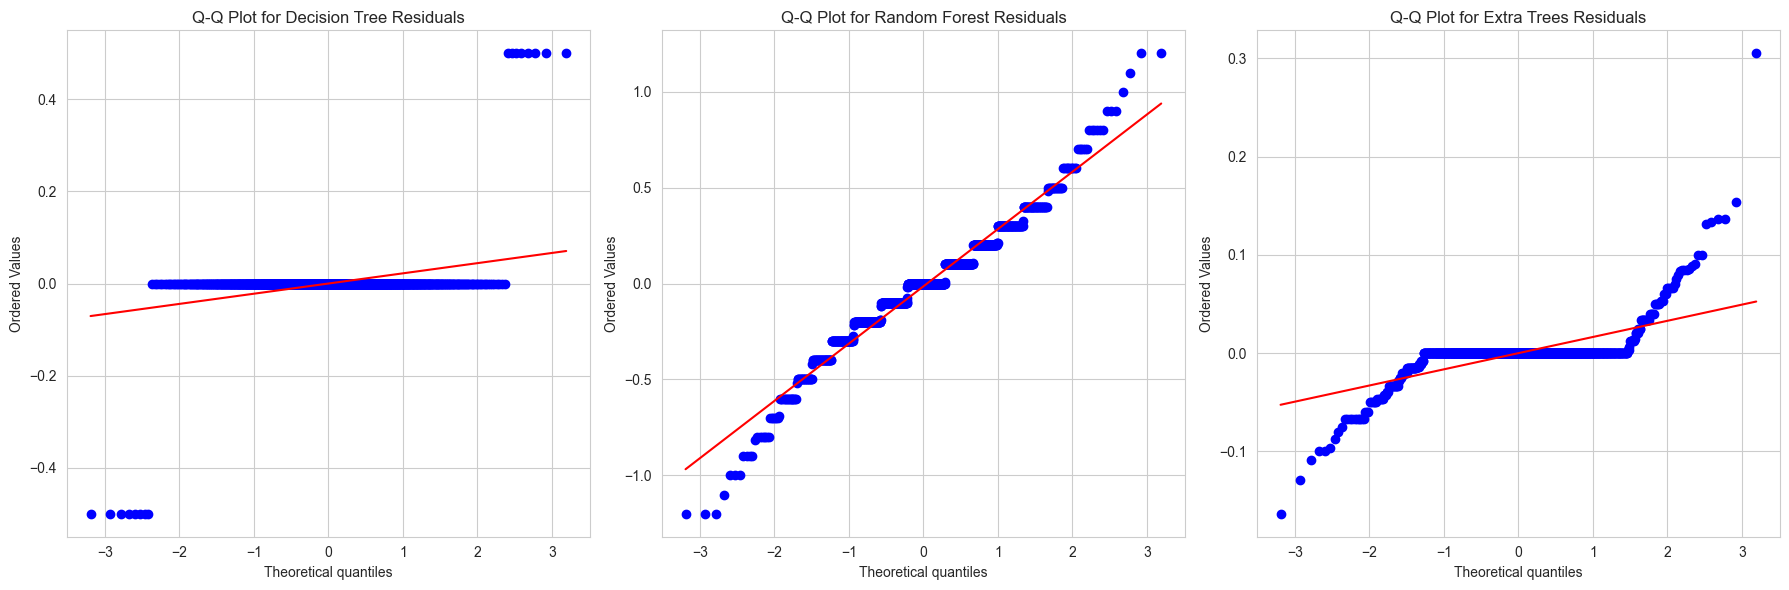

In [93]:
# Plot the Q-Q plot for the predictions of each model
import scipy.stats as stats

# Create a subplot grid for Q-Q plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Loop through each model and create a Q-Q plot of the predictions
for i, (model_name, model) in enumerate(evaluation_models.items()):
    model.fit(X_test, y_test)
    predictions = model.predict(X_test)
    residuals = y_test - predictions

    # Create a Q-Q plot for the residuals
    stats.probplot(residuals, dist="norm", plot=axes[i])

    # Set the title for the current subplot
    axes[i].set_title(f'Q-Q Plot for {model_name} Residuals')

# Adjust layout and display the plots
plt.tight_layout()
plt.show()

## Interpretation of the Q-Q Plots

A Q-Q plot compares the distribution of model residuals against a theoretical normal distribution. If the residuals lie close to the reference line, the errors are approximately normal. Large deviations from the line indicate non-normality, skewness, heavy tails, or discrete prediction behavior.

### 1. Decision Tree Regressor
The residuals are heavily concentrated at zero, with a few large jumps at the ends. This creates a strong departure from the straight reference line.

**Interpretation:**
- The residuals are **not normally distributed**.
- The model appears to produce **discrete, step-like predictions**, which is typical of a single decision tree.
- This is usually a sign of **high variance / overfitting behavior** rather than smooth generalization.

### 2. Random Forest Regressor
The residuals follow the reference line much more closely than the other two models, especially in the middle portion.

**Interpretation:**
- This is the **best-behaved residual distribution** among the three models.
- Residuals are **closest to normal**, although some tail deviations are still present.
- This suggests the Random Forest model has the **most reliable and consistent predictive behavior** of the three.

### 3. Extra Trees Regressor
The residuals show a noticeable flat cluster near zero and a visible bend away from the reference line, especially in the tails.

**Interpretation:**
- The residuals are also **not normally distributed**.
- The model captures many observations with very small errors, but the systematic curve indicates **asymmetry and tail distortion**.
- Compared with Random Forest, the Extra Trees model appears **less aligned with normal residual assumptions**.
- Its predictions may be more randomized and less stable in error structure.

## Overall Conclusion
- **Random Forest** shows the best Q-Q plot and therefore the most reasonable residual behavior.
- **Decision Tree** performs the worst in terms of residual normality, with strong discreteness and tail deviations.
- **Extra Trees** is better than a single Decision Tree in some respects, but still shows clear non-normality and structured error patterns.

## Practical Takeaway
For predictive regression, perfect normality is not mandatory, but the Q-Q plot is useful for checking error behavior.  
Among these three models, **Random Forest is the most trustworthy choice** based on the residual distribution shown.

# Port the Classifier Model to C Code
## emlearn - Machine Learning for Tiny Embedded Systems
```emlearn``` is an open-source Python library that allows converting scikit-learn and Keras models to efficient C code. This makes it easy to deploy to any microcontroller with, while keeping Python-based workflow that is familiar to Machine Learning Engineers.

To install emlearn to convert models in Python, use ```pip install emlearn```

In [ ]:
# Convert model using emlearn
import emlearn

# Convert the trained Decision Tree Regressor to C++ code using emlearn
dt_regressor_c_code = emlearn.convert(dt_regressor, method='inline', dtype='float', return_type='regressor')
rf_regressor_c_code = emlearn.convert(rf_regressor, method='inline', dtype='float', return_type='regressor')
et_regressor_c_code = emlearn.convert(et_regressor, method='inline', dtype='float', return_type='regressor')

# Generate and save the C code to a header file
dt_regressor_c_code.save(file='DecisionTreeRegressor.h', name='DecisionTreeRegressor')
rf_regressor_c_code.save(file='RandomForestRegressor.h', name='RandomForestRegressor')
et_regressor_c_code.save(file='ExtraTreesRegressor.h', name='ExtraTreesRegressor')

'\n\n\n    // !!! This file is generated using emlearn !!!\n\n    #include <stdint.h>\n    \n\nstatic inline float ExtraTreesRegressor_tree_0(const float *features, int32_t features_length) {\n          if (features[6] < 0.709082f) {\n              if (features[6] < 0.267130f) {\n                  if (features[1] < 0.354817f) {\n                      if (features[1] < 0.188973f) {\n                          if (features[6] < 0.193343f) {\n                              if (features[0] < 0.299516f) {\n                                  if (features[3] < 0.429888f) {\n                                      if (features[4] < 0.234158f) {\n                                          if (features[0] < 0.288240f) {\n                                              if (features[3] < 0.283190f) {\n                                                  if (features[3] < 0.275956f) {\n                                                      if (features[5] < 0.422054f) {\n                                       